In [18]:
import os, sys

# Go up THREE levels (project root directory)
project_root = os.path.dirname(os.path.dirname(os.getcwd()))
project_root
# Append the new path to sys.path
if project_root not in sys.path:
    sys.path.append(project_root)
    print("Project root added to sys.path")
else:
    print("Project root already in sys.path")

Project root already in sys.path


In [19]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from matplotlib import animation
from utils import gro_processing

In [20]:
G = nx.dodecahedral_graph()
pos = nx.spectral_layout(G, dim=3)
nodes = np.array([pos[v] for v in G])
edges = np.array([(pos[u], pos[v]) for u, v in G.edges()])

In [21]:
centroids_arr = np.loadtxt("../../data/processed/user-defined-centroids.csv",delimiter=',',skiprows=1,usecols=range(1,4))

pairs = np.loadtxt("../../data/processed/unblocked_pairs_2.csv",delimiter=',',dtype=int)

edges_arr = np.empty(shape=(pairs.shape[0],2,3))
numerator = 0
for (p,q) in pairs:
    edges_arr[numerator] = [centroids_arr[p-1],centroids_arr[q-1]]
    numerator += 1
edges_arr

array([[[1.68453333e+00, 4.85533333e-01, 3.79533333e-01],
        [2.55302667e-01, 6.62302667e-01, 1.11453027e+01]],

       [[1.68453333e+00, 4.85533333e-01, 3.79533333e-01],
        [4.92200000e-01, 9.42200000e-01, 2.66200000e-01]],

       [[1.68453333e+00, 4.85533333e-01, 3.79533333e-01],
        [6.25936000e-01, 1.11049360e+01, 1.05329360e+01]],

       ...,

       [[1.01928333e+01, 2.31983333e+00, 2.41883333e+00],
        [2.06266667e-03, 2.26106267e+00, 2.25206267e+00]],

       [[8.99126600e+00, 2.75266000e-01, 6.00326600e+00],
        [8.28920000e+00, 9.58200000e-01, 6.98120000e+00]],

       [[4.18340000e+00, 3.66240000e+00, 3.95340000e+00],
        [4.42053333e+00, 4.53953333e+00, 3.72153333e+00]]],
      shape=(3597, 2, 3))

In [22]:
nodes = centroids_arr
edges = edges_arr 

MovieWriter ffmpeg unavailable; using Pillow instead.


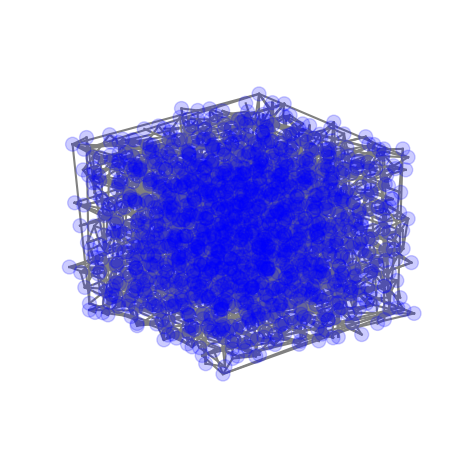

In [14]:
def init():
    ax.clear()
    ax.scatter(*nodes.T, alpha=0.2, s=100, color="blue")
    for vizedge in edges:
        ax.plot(*vizedge.T, color="gray")
    ax.grid(False)
    ax.set_axis_off()


def _frame_update(index):
    ax.view_init(index * 0.2, index * 0.5)


fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")
fig.tight_layout()

ani = animation.FuncAnimation(
    fig,
    _frame_update,
    init_func=init,
    interval=50,
    cache_frame_data=False,
    frames=100,
)

ani.save(filename="temp.gif")
plt.show()